# Preprocessing Pipeline

Loads the merged XDF output and applies physiological signal preprocessing using NeuroKit2.

**Input:** One merged CSV (from XDF Analyzer) containing any number of participants/conditions stacked together.  
**Signals processed:** PPG (Commander + IS), EDA (Commander + IS)  
**Output:** Per-group cleaned signals and extracted features (HRV, SCR peaks).

In [2]:
import pandas as pd
import numpy as np
import neurokit2 as nk
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
# --- Configuration ---
DATA_PATH = "merged_data_23.csv"   # Change to the combined multi-group CSV when available

# Sampling rate of the merged data (PPG_GRN_C is the base at 25 Hz)
SAMPLING_RATE = 25  # Hz

# Group columns — all present columns from this list are used to split the data into groups
GROUP_COLS = ["ID", "Condition"]

# Reliability segments to keep (None = keep all rows including "No Video")
# Set to a list to filter, e.g. ["Reliable", "Unreliable", "Mix"]
RELIABILITY_FILTER = None

In [4]:
def load_data(path, reliability_filter=None):
    """
    Load the merged XDF output CSV and optionally filter by reliability segment.
    Returns a DataFrame sorted by ID, Condition, and timestamp.
    """
    df = pd.read_csv(path)

    # Build datetime index from Date + Time columns if present
    if "Date" in df.columns and "Time" in df.columns:
        df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], errors="coerce")

    if reliability_filter is not None and "Reliability" in df.columns:
        before = len(df)
        df = df[df["Reliability"].isin(reliability_filter)].reset_index(drop=True)
        print(f"Reliability filter '{reliability_filter}': {before} → {len(df)} rows")

    # Sort so each group's rows are contiguous and in time order
    sort_cols = [c for c in ["ID", "Condition", "timestamp"] if c in df.columns]
    df = df.sort_values(sort_cols).reset_index(drop=True)

    groups_found = df[GROUP_COLS].drop_duplicates() if all(c in df.columns for c in GROUP_COLS) else None
    print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
    if groups_found is not None:
        print(f"Groups found ({len(groups_found)}):")
        print(groups_found.to_string(index=False))
    return df


df = load_data(DATA_PATH, RELIABILITY_FILTER)
df.head(3)

Loaded 69988 rows, 41 columns
Groups found (1):
 ID Condition
 23       Low


,ID,Condition,Date,Time,timestamp,DataSyncMarker,DataSyncMarker_channel_1,Reliability,PPG_GRN_C,PPG_RED_C,...,Neon Companion_Neon Gaze_OpticalAxisZ_right,PPG_GRN_IS,PPG_RED_IS,PPG_IR_IS,EDA_IS,HR_IS,TEMP_IS,THERM_IS,keyboard_IS,datetime
0,23,Low,2025-08-28,10:23:14.811,160571.037,NaN,NaN,NaN,7839.0,130854.0,...,0.990039,2880.0,73858.0,158966.0,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:23:14.811
1,23,Low,2025-08-28,10:23:14.852,160571.078,NaN,NaN,NaN,7833.0,130831.0,...,0.989490,2894.0,73864.0,158984.0,0.030146,NaN,NaN,NaN,NaN,2025-08-28 10:23:14.852
2,23,Low,2025-08-28,10:23:14.892,160571.118,NaN,NaN,NaN,7810.0,130825.0,...,0.991017,2889.0,73871.0,159034.0,0.030146,NaN,32.746,NaN,NaN,2025-08-28 10:23:14.892


In [ ]:
def preprocess_ppg(signal_series, sampling_rate=25, label="PPG",
                   method="langevin2021"):
    """
    Clean a PPG signal and extract instantaneous heart rate and HRV features.

    Returns
    -------
    signals : pd.DataFrame  — cleaned signal, peaks, rate aligned to the original index
    info    : dict          — peak indices and other metadata from NeuroKit2
    hrv     : pd.DataFrame  — HRV frequency + time-domain features (single row)
    """
    raw = signal_series.values.astype(float)
    valid_mask = ~np.isnan(raw)

    if valid_mask.sum() < sampling_rate * 10:
        print(f"  [{label}] Skipped: fewer than 10 seconds of valid data")
        return None, None, None

    clean_input = raw[valid_mask]

    signals, info = nk.ppg_process(clean_input, sampling_rate=sampling_rate,
                                   method=method)
    signals.index = signal_series.index[valid_mask]

    try:
        hrv = nk.hrv(info, sampling_rate=sampling_rate, show=False)
    except Exception as e:
        print(f"  [{label}] HRV extraction failed: {e}")
        hrv = None

    n_peaks = int(signals["PPG_Peaks"].sum())
    duration_s = len(clean_input) / sampling_rate
    print(f"  [{label}] {len(clean_input)} samples ({duration_s:.1f}s), "
          f"{n_peaks} peaks detected (method={method})")
    return signals, info, hrv


def preprocess_eda(signal_series, sampling_rate=25, label="EDA"):
    """
    Clean an EDA signal and decompose it into tonic (SCL) and phasic (SCR) components.

    Returns
    -------
    signals : pd.DataFrame  — cleaned, tonic, phasic, SCR peaks, aligned to original index
    info    : dict          — SCR peak indices and amplitudes
    """
    raw = signal_series.values.astype(float)
    valid_mask = ~np.isnan(raw)

    if valid_mask.sum() < sampling_rate * 10:
        print(f"  [{label}] Skipped: fewer than 10 seconds of valid data")
        return None, None

    clean_input = raw[valid_mask]

    signals, info = nk.eda_process(clean_input, sampling_rate=sampling_rate)
    signals.index = signal_series.index[valid_mask]

    n_scr = int(signals["SCR_Peaks"].sum()) if "SCR_Peaks" in signals.columns else 0
    duration_s = len(clean_input) / sampling_rate
    print(f"  [{label}] {len(clean_input)} samples ({duration_s:.1f}s), {n_scr} SCR peaks detected")
    return signals, info

In [6]:
def preprocess_group(group_df, group_label, sampling_rate=25):
    """
    Run the full preprocessing pipeline for one participant/condition group.

    Returns a dict keyed by signal name, e.g. "ppg_GRN_C", "ppg_RED_IS", "eda_C".
    Each value is a dict with 'signals', 'info', and (for PPG) 'hrv'.
    """
    print(f"\n{'='*60}")
    print(f"Group: {group_label}  ({len(group_df)} rows, "
          f"{len(group_df)/sampling_rate:.1f}s)")
    print(f"{'='*60}")

    results = {}

    ppg_cols = {
        "ppg_GRN_C":  "PPG_GRN_C",
        "ppg_RED_C":  "PPG_RED_C",
        "ppg_IR_C":   "PPG_IR_C",
        "ppg_GRN_IS": "PPG_GRN_IS",
        "ppg_RED_IS": "PPG_RED_IS",
        "ppg_IR_IS":  "PPG_IR_IS",
    }
    for key, col in ppg_cols.items():
        if col in group_df.columns and group_df[col].notna().any():
            sig, info, hrv = preprocess_ppg(group_df[col], sampling_rate, label=col)
            results[key] = {"signals": sig, "info": info, "hrv": hrv}
        else:
            print(f"  [{col}] Column missing or all-NaN — skipped")

    eda_cols = {
        "eda_C":  "EDA_C",
        "eda_IS": "EDA_IS",
    }
    for key, col in eda_cols.items():
        if col in group_df.columns and group_df[col].notna().any():
            sig, info = preprocess_eda(group_df[col], sampling_rate, label=col)
            results[key] = {"signals": sig, "info": info}
        else:
            print(f"  [{col}] Column missing or all-NaN — skipped")

    return results

In [7]:
# --- Run pipeline over all groups ---

active_group_cols = [c for c in GROUP_COLS if c in df.columns]

if active_group_cols:
    grouped = df.groupby(active_group_cols, sort=False)
else:
    grouped = [("all", df)]

all_results = {}

for group_key, group_df in grouped:
    label = group_key if isinstance(group_key, str) else "_".join(str(k) for k in group_key)
    all_results[label] = preprocess_group(group_df.reset_index(drop=True), label, SAMPLING_RATE)

print(f"\nPreprocessing complete. Groups processed: {list(all_results.keys())}")


Group: 23_Low  (69988 rows, 2799.5s)
  [PPG_GRN_C] 69988 samples (2799.5s), 400 peaks detected
  [PPG_RED_C] 69988 samples (2799.5s), 434 peaks detected
  [PPG_IR_C] 69988 samples (2799.5s), 598 peaks detected
  [PPG_GRN_IS] 69988 samples (2799.5s), 208 peaks detected
  [PPG_RED_IS] 69988 samples (2799.5s), 226 peaks detected
  [PPG_IR_IS] 69988 samples (2799.5s), 331 peaks detected
  [EDA_C] 69988 samples (2799.5s), 2 SCR peaks detected
  [EDA_IS] 69987 samples (2799.5s), 5 SCR peaks detected

Preprocessing complete. Groups processed: ['23_Low']


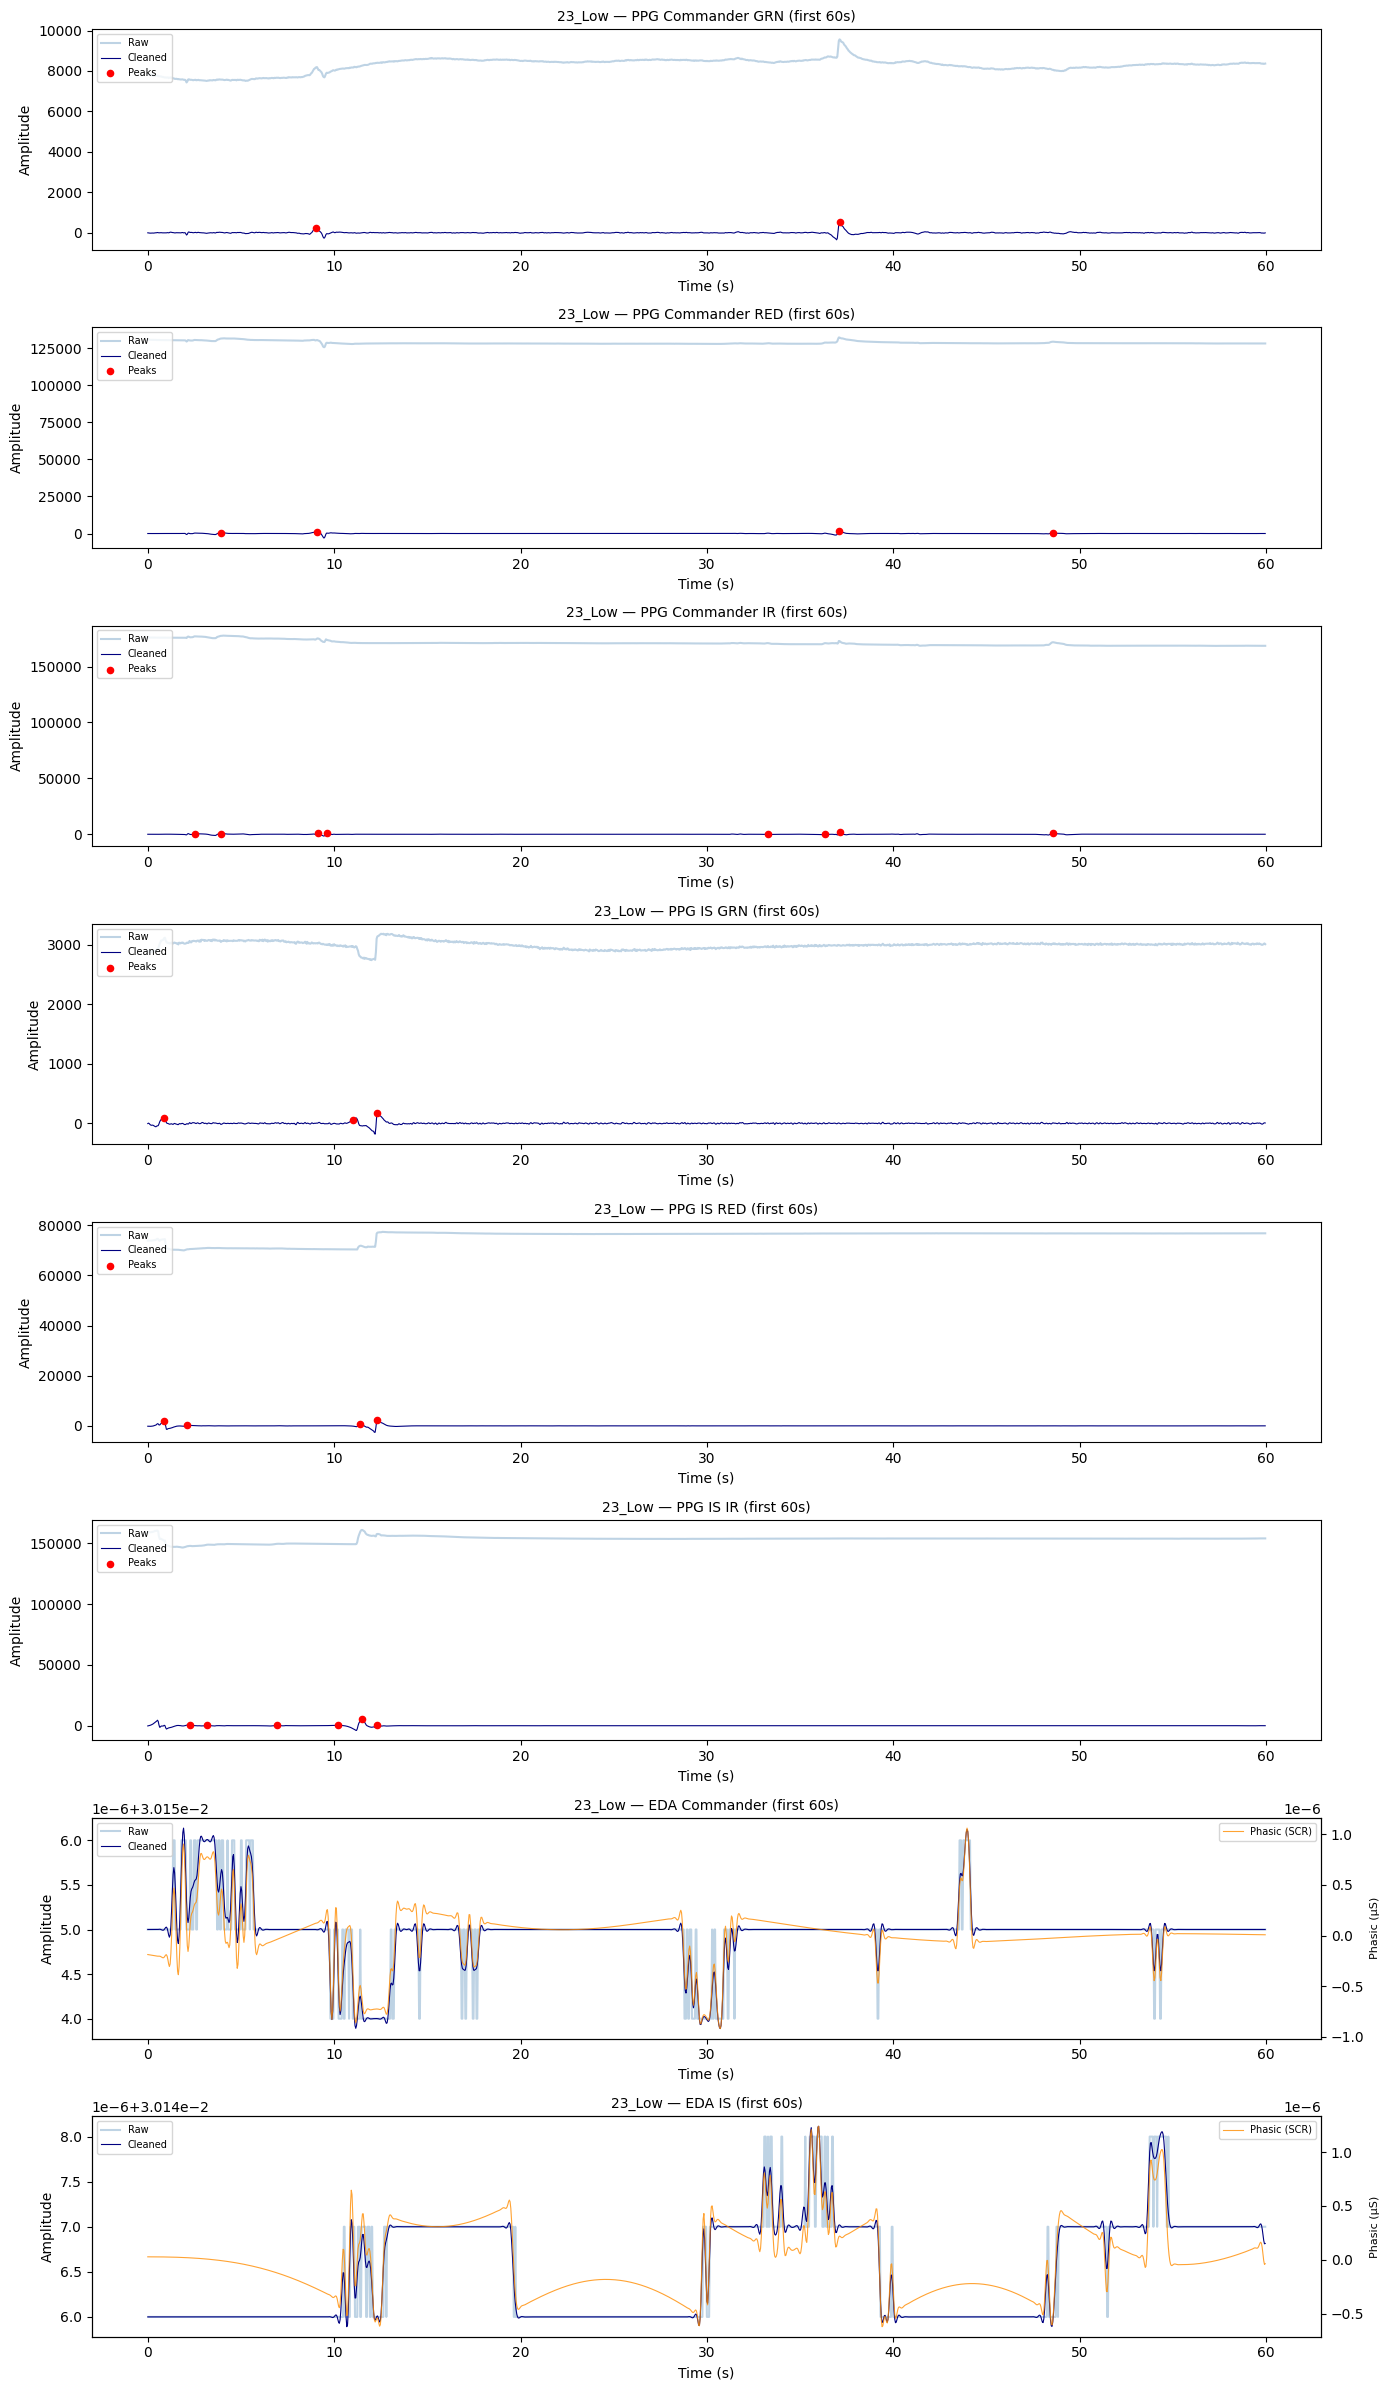

In [8]:
PPG_STREAMS = [
    ("ppg_GRN_C",  "PPG_GRN_C",  "PPG Commander GRN"),
    ("ppg_RED_C",  "PPG_RED_C",  "PPG Commander RED"),
    ("ppg_IR_C",   "PPG_IR_C",   "PPG Commander IR"),
    ("ppg_GRN_IS", "PPG_GRN_IS", "PPG IS GRN"),
    ("ppg_RED_IS", "PPG_RED_IS", "PPG IS RED"),
    ("ppg_IR_IS",  "PPG_IR_IS",  "PPG IS IR"),
]
EDA_STREAMS = [
    ("eda_C",  "EDA_C",  "EDA Commander"),
    ("eda_IS", "EDA_IS", "EDA IS"),
]


def plot_group(group_label, group_df, results, sampling_rate=25, n_seconds=60):
    """
    Diagnostic plot: raw vs. cleaned signal for all PPG variants and EDA.
    PPG panels show detected peaks; EDA panels overlay the phasic (SCR) component.
    """
    plot_items = [
        (key, raw_col, "PPG_Clean", title)
        for key, raw_col, title in PPG_STREAMS
        if key in results and results[key]["signals"] is not None
    ] + [
        (key, raw_col, "EDA_Clean", title)
        for key, raw_col, title in EDA_STREAMS
        if key in results and results[key]["signals"] is not None
    ]

    if not plot_items:
        print(f"[{group_label}] Nothing to plot.")
        return

    n_preview = n_seconds * sampling_rate
    fig, axes = plt.subplots(len(plot_items), 1, figsize=(14, 3 * len(plot_items)), sharex=False)
    if len(plot_items) == 1:
        axes = [axes]

    for ax, (key, raw_col, clean_col, title) in zip(axes, plot_items):
        signals = results[key]["signals"]

        if raw_col in group_df.columns:
            raw = group_df[raw_col].values[:n_preview]
            t_raw = np.arange(len(raw)) / sampling_rate
            ax.plot(t_raw, raw, alpha=0.35, color="steelblue", label="Raw")

        cleaned = signals[clean_col].values[:n_preview]
        t_clean = np.arange(len(cleaned)) / sampling_rate
        ax.plot(t_clean, cleaned, color="navy", linewidth=0.8, label="Cleaned")

        if "PPG_Peaks" in signals.columns:
            peak_mask = signals["PPG_Peaks"].values[:n_preview].astype(bool)
            ax.scatter(t_clean[peak_mask], cleaned[peak_mask],
                       color="red", s=20, zorder=5, label="Peaks")

        if "EDA_Phasic" in signals.columns:
            phasic = signals["EDA_Phasic"].values[:n_preview]
            ax2 = ax.twinx()
            ax2.plot(t_clean, phasic, color="darkorange", linewidth=0.8,
                     alpha=0.8, label="Phasic (SCR)")
            ax2.set_ylabel("Phasic (µS)", fontsize=8)
            ax2.legend(loc="upper right", fontsize=7)

        ax.set_title(f"{group_label} — {title} (first {n_seconds}s)", fontsize=10)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude")
        ax.legend(loc="upper left", fontsize=7)

    plt.tight_layout()
    plt.show()


# Plot each group
for label, results in all_results.items():
    active_cols = [c for c in GROUP_COLS if c in df.columns]
    if active_cols:
        key_vals = label.split("_")
        mask = pd.Series([True] * len(df))
        for col, val in zip(active_cols, key_vals):
            mask &= df[col].astype(str) == val
        group_df = df[mask].reset_index(drop=True)
    else:
        group_df = df

    plot_group(label, group_df, results, SAMPLING_RATE, n_seconds=60)

In [9]:
def summarize_hrv(all_results):
    """
    Collect HRV summary rows from all groups and PPG streams into a single DataFrame.
    One row per (group, PPG stream).
    """
    rows = []
    for group_label, results in all_results.items():
        for key, _, title in PPG_STREAMS:
            if key in results and results[key]["hrv"] is not None:
                hrv_row = results[key]["hrv"].copy()
                hrv_row.insert(0, "Stream", title)
                hrv_row.insert(0, "Group", group_label)
                rows.append(hrv_row)
    if not rows:
        print("No HRV data available.")
        return None
    return pd.concat(rows, ignore_index=True)


hrv_summary = summarize_hrv(all_results)
if hrv_summary is not None:
    display(hrv_summary)

,Group,Stream,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,...,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC,HRV_Symbolic_EqualProb4_0V,HRV_Symbolic_EqualProb4_1V,HRV_Symbolic_EqualProb4_2LV,HRV_Symbolic_EqualProb4_2UV
0,23_Low,PPG Commander GRN,6992.781955,28544.400608,16158.103158,15906.757512,109512.596866,17584.384930,6251.774594,27440.176597,...,0.238167,0.189664,0.102346,1.959065,1.531811,0.498059,0.100756,0.440806,0.130982,0.327456
1,23_Low,PPG Commander RED,6455.519630,32062.294852,11537.682962,19029.845876,11216.369969,22991.378923,6275.950548,26163.112004,...,0.243025,0.190030,0.088265,1.956106,1.417870,0.566352,0.153132,0.368910,0.120650,0.357309
2,23_Low,PPG Commander IR,4683.618090,14297.276515,10923.663215,9324.820632,7481.045696,11370.762900,1761.662855,10223.480553,...,0.471474,0.374234,0.226284,1.913218,1.626749,0.679648,0.110924,0.352941,0.112605,0.423529
3,23_Low,PPG IS GRN,13516.135266,45668.464195,56095.727381,16768.402238,36037.452318,29449.636588,96412.861928,36036.004356,...,0.279348,0.240546,0.144051,1.786556,1.586935,0.631832,0.121951,0.390244,0.126829,0.360976
4,23_Low,PPG IS RED,12435.022222,60294.502267,37828.399772,33936.350529,12362.920353,39419.701062,12427.889293,56229.942320,...,0.171643,0.138393,0.083342,1.928716,1.547327,0.451463,0.103139,0.457399,0.103139,0.336323
5,23_Low,PPG IS IR,8474.303030,27454.685013,48338.306417,18965.512535,58179.356940,21661.256306,41716.353732,36658.223180,...,0.375528,0.289389,0.111681,1.838166,1.790463,0.481697,0.115854,0.384146,0.152439,0.347561


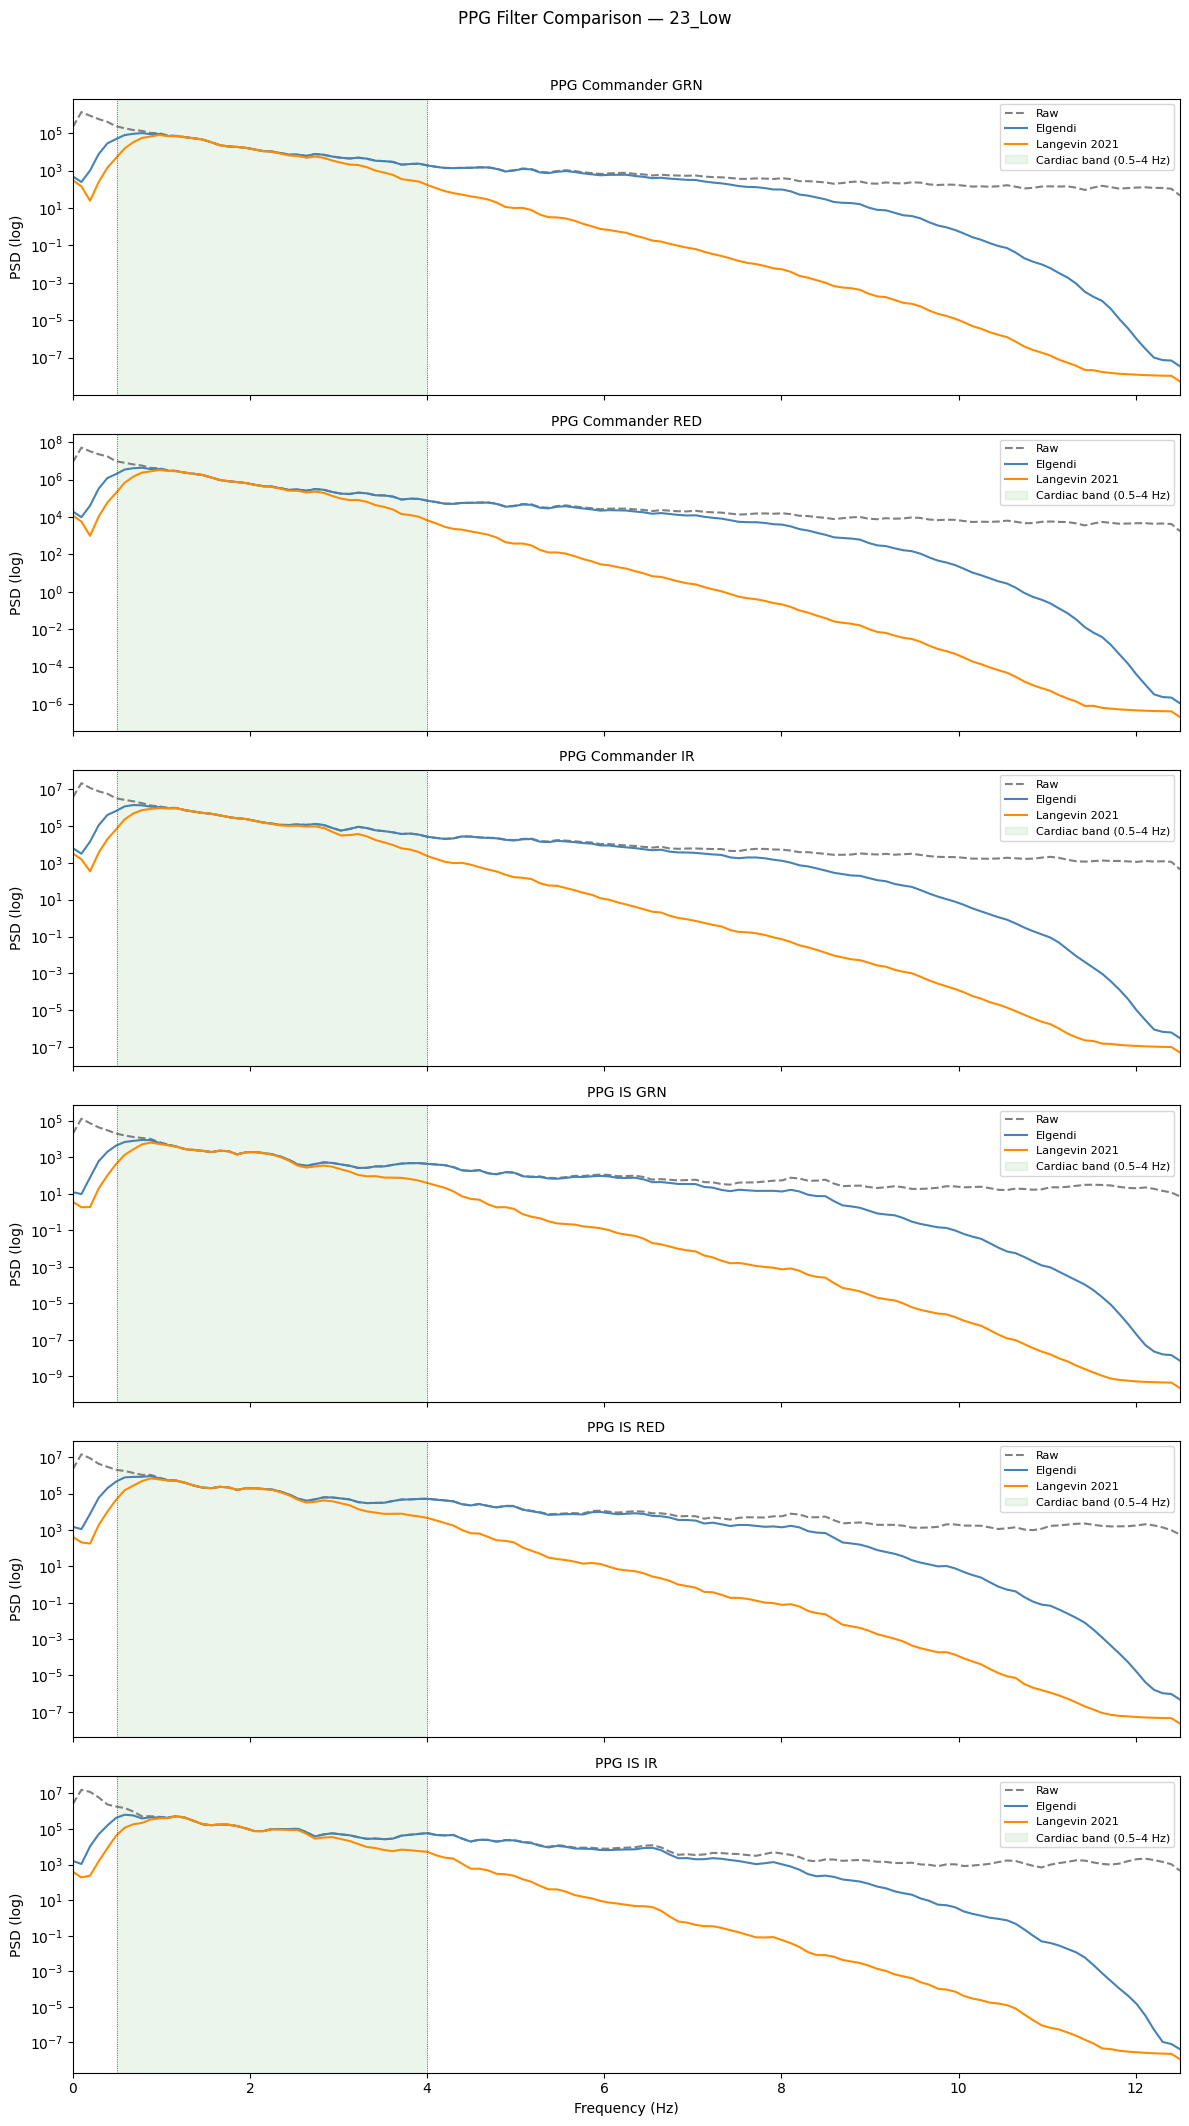

In [10]:
from scipy.signal import welch

def plot_ppg_filter_comparison(group_df, group_label, sampling_rate=25):
    """
    For each PPG stream in the group, plot the power spectral density (PSD)
    of the raw signal and both filter options side-by-side so you can compare
    how each method shapes the frequency content.

    The shaded region marks the cardiac band (0.5–4 Hz, i.e. 30–240 BPM).
    """
    present = [(key, raw_col, title)
               for key, raw_col, title in PPG_STREAMS
               if raw_col in group_df.columns and group_df[raw_col].notna().any()]

    if not present:
        print(f"[{group_label}] No PPG columns found.")
        return

    fig, axes = plt.subplots(len(present), 1,
                             figsize=(12, 3.5 * len(present)), sharex=True)
    if len(present) == 1:
        axes = [axes]

    fig.suptitle(f"PPG Filter Comparison — {group_label}", fontsize=12, y=1.01)

    for ax, (key, raw_col, title) in zip(axes, present):
        raw = group_df[raw_col].dropna().values.astype(float)

        elgendi   = nk.ppg_clean(raw, sampling_rate=sampling_rate, method="elgendi")
        langevin  = nk.ppg_clean(raw, sampling_rate=sampling_rate, method="langevin2021")

        for signal, label, color, ls in [
            (raw,      "Raw",            "gray",       "--"),
            (elgendi,  "Elgendi",        "steelblue",  "-"),
            (langevin, "Langevin 2021",  "darkorange", "-"),
        ]:
            freqs, psd = welch(signal, fs=sampling_rate, nperseg=min(256, len(signal)))
            ax.semilogy(freqs, psd, linestyle=ls, color=color, linewidth=1.5, label=label)

        # Cardiac band
        ax.axvspan(0.5, 4.0, alpha=0.08, color="green", label="Cardiac band (0.5–4 Hz)")
        ax.axvline(0.5, color="green", linewidth=0.6, linestyle=":")
        ax.axvline(4.0, color="green", linewidth=0.6, linestyle=":")

        ax.set_xlim(0, sampling_rate / 2)
        ax.set_ylabel("PSD (log)")
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=8, loc="upper right")

    axes[-1].set_xlabel("Frequency (Hz)")
    plt.tight_layout()
    plt.show()


# Pick the first group (change index or label to inspect others)
first_label = list(all_results.keys())[0]
active_cols = [c for c in GROUP_COLS if c in df.columns]
if active_cols:
    key_vals = first_label.split("_")
    mask = pd.Series([True] * len(df))
    for col, val in zip(active_cols, key_vals):
        mask &= df[col].astype(str) == val
    group_df = df[mask].reset_index(drop=True)
else:
    group_df = df

plot_ppg_filter_comparison(group_df, first_label, SAMPLING_RATE)